In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': False, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]

In [2]:
t_array = np.linspace(0,12,int(1e3))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)

#Gal1, with everything
gal1 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp)
Z_Fe_1 = gal1.compute_z_Fe()
Z_O_1 = gal1.compute_z_O()
Z_Mn_1 = gal1.compute_z_Mn()

In [3]:
#Gal2, with only CCSN
gal2 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, m_Fe_Ia=0, K_Fe_Ia=0)
Z_Fe_2 = gal2.compute_z_Fe()
Z_O_2 = gal2.compute_z_O()
Z_Mn_2 = gal2.compute_z_Mn()


#Gal3, with only Ia
gal3 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, m_Fe_cc=0, m_o_cc=0)
Z_Fe_3 = gal3.compute_z_Fe()
Z_O_3 = gal3.compute_z_O()
Z_Mn_3 = gal3.compute_z_Mn()

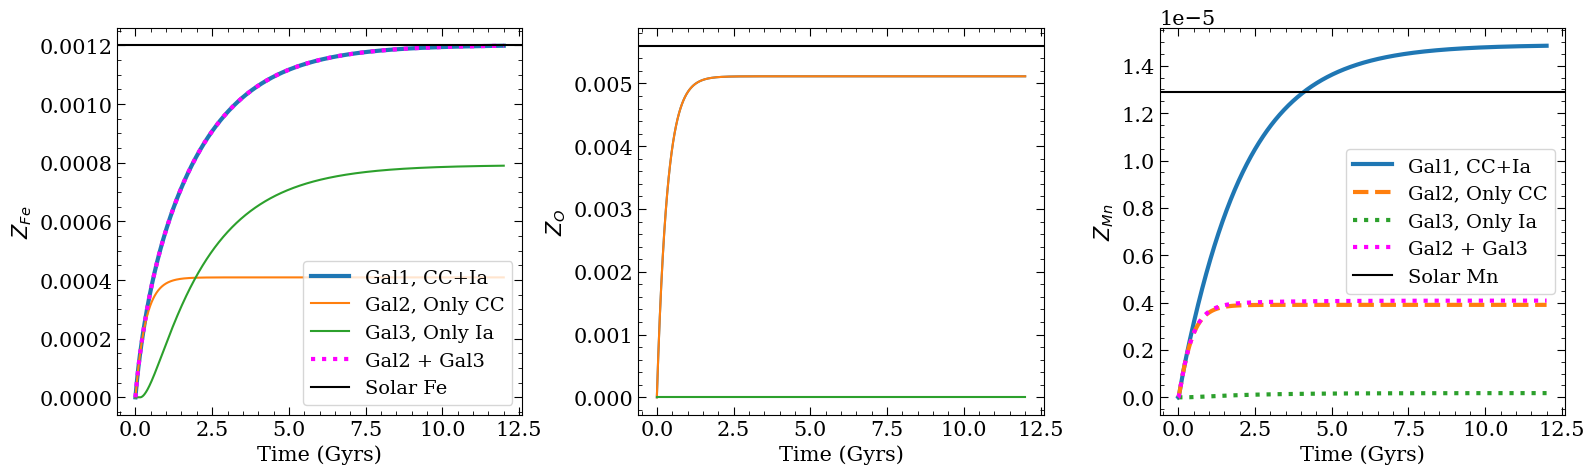

In [4]:
plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
plt.plot(t_array, Z_Fe_1, label = 'Gal1, CC+Ia', lw=3)
plt.plot(t_array, Z_Fe_2, label = 'Gal2, Only CC')
plt.plot(t_array, Z_Fe_3, label = 'Gal3, Only Ia')
plt.plot(t_array, Z_Fe_2 + Z_Fe_3, label = 'Gal2 + Gal3', linestyle=':', lw=3, color = 'magenta')
plt.axhline(gal1.SolarFe, color = 'black', label = 'Solar Fe')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Fe}$')
plt.legend()


plt.subplot(1,3,2)
plt.plot(t_array, Z_O_1, label = 'Gal1, CC+Ia')
plt.plot(t_array, Z_O_2, label = 'Gal2, Only CC')
plt.plot(t_array, Z_O_3, label = 'Gal3, Only Ia')
plt.axhline(gal1.SolarO, color = 'black', label = 'Solar O')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{O}$')


plt.subplot(1,3,3)
plt.plot(t_array, Z_Mn_1, label = 'Gal1, CC+Ia', lw=3)
plt.plot(t_array, Z_Mn_2, label = 'Gal2, Only CC', linestyle='--', lw=3)
plt.plot(t_array, Z_Mn_3, label = 'Gal3, Only Ia', linestyle = ':', lw=3)
plt.plot(t_array, Z_Mn_3 + Z_Mn_2, label = 'Gal2 + Gal3', linestyle=':', lw=3, color = 'magenta')
plt.axhline(gal1.SolarMn, color = 'black', label = 'Solar Mn')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}$')
plt.legend()
plt.tight_layout()

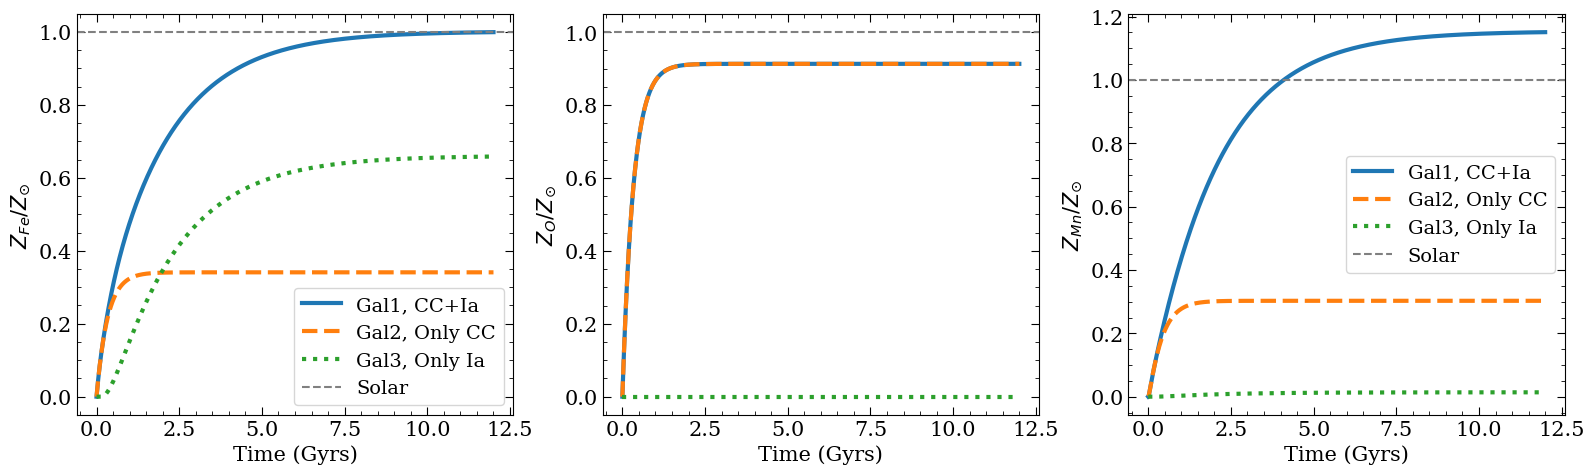

In [5]:
plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
plt.plot(t_array, Z_Fe_1/gal1.SolarFe, label = 'Gal1, CC+Ia', lw=3)
plt.plot(t_array, Z_Fe_2/gal1.SolarFe, label = 'Gal2, Only CC', linestyle='--', lw=3)
plt.plot(t_array, Z_Fe_3/gal1.SolarFe, label = 'Gal3, Only Ia', linestyle = ':', lw=3)
plt.axhline(1, label = 'Solar', color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Fe}/Z_{\odot}$')
plt.legend()


plt.subplot(1,3,2)
plt.plot(t_array, Z_O_1/gal1.SolarO, label = 'Gal1, CC+Ia', lw=3)
plt.plot(t_array, Z_O_2/gal1.SolarO, label = 'Gal2, Only CC', linestyle='--', lw=3)
plt.plot(t_array, Z_O_3/gal1.SolarO, label = 'Gal3, Only Ia', linestyle = ':', lw=3)
plt.axhline(1, label = 'Solar', color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{O}/Z_{\odot}$')


plt.subplot(1,3,3)
plt.plot(t_array, Z_Mn_1/gal1.SolarMn, label = 'Gal1, CC+Ia', lw=3)
plt.plot(t_array, Z_Mn_2/gal1.SolarMn, label = 'Gal2, Only CC', linestyle='--', lw=3)
plt.plot(t_array, Z_Mn_3/gal1.SolarMn, label = 'Gal3, Only Ia', linestyle = ':', lw=3)
plt.axhline(1, label = 'Solar', color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{\odot}$')
plt.legend()
plt.tight_layout()

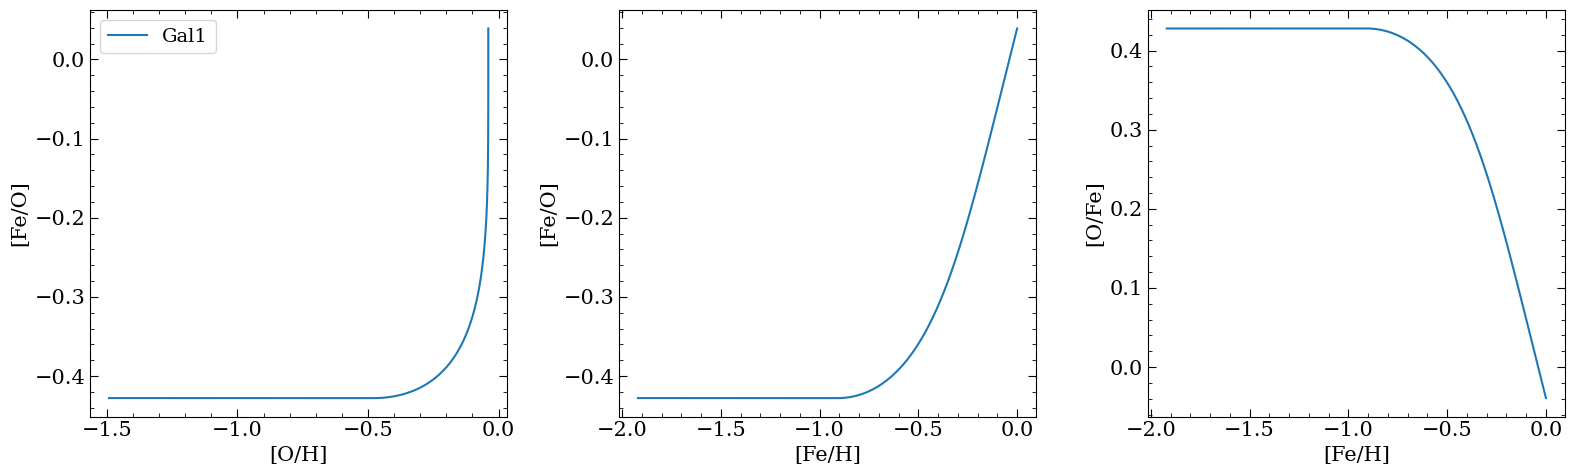

In [6]:
plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
plt.plot(gal1.O_H[1:], gal1.Fe_O[1:], label = 'Gal1')
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')
plt.legend()


plt.subplot(1,3,2)
plt.plot(gal1.Fe_H[1:], gal1.Fe_O[1:])
plt.xlabel('[Fe/H]')
plt.ylabel('[Fe/O]')

plt.subplot(1,3,3)
plt.plot(gal1.Fe_H[1:], gal1.O_Fe[1:])
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe]')

plt.tight_layout()

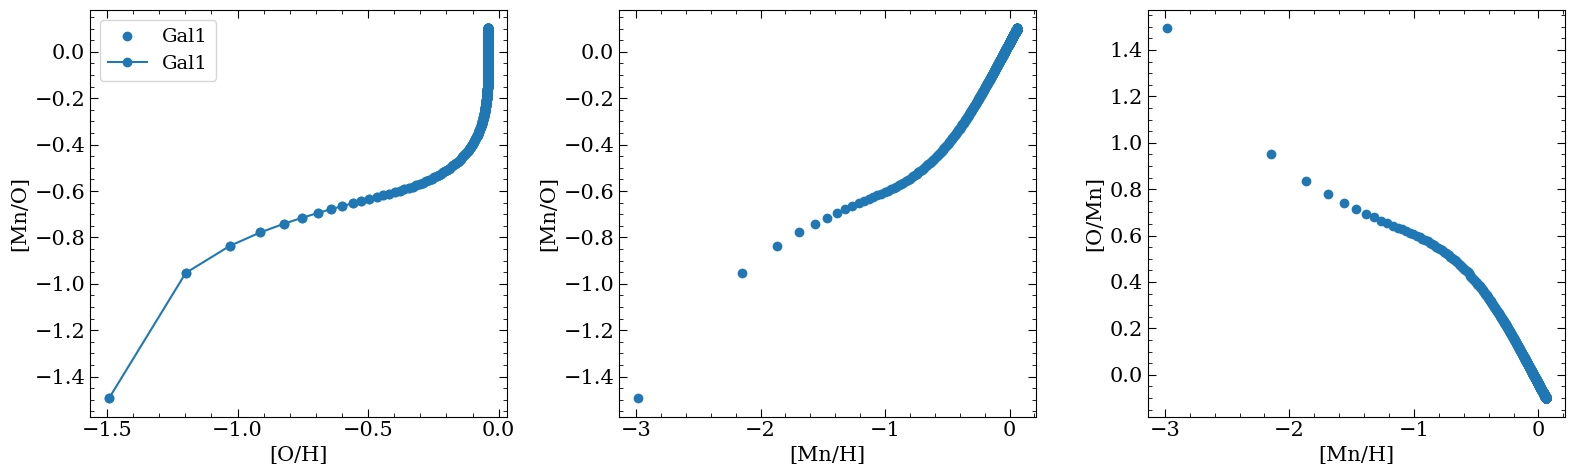

In [7]:
Mn_O = gal1.Mn_H - gal1.O_H
Mn_Fe = gal1.Mn_H - gal1.Fe_H
O_Mn = gal1.O_H - gal1.Mn_H
Fe_Mn = gal1.Fe_H - gal1.Mn_H

plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
plt.scatter(gal1.O_H[1:], Mn_O[1:], label = 'Gal1')
plt.plot(gal1.O_H[1:], Mn_O[1:], label = 'Gal1', marker='o')
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')
plt.legend()


plt.subplot(1,3,2)
plt.scatter(gal1.Mn_H[1:], Mn_O[1:])
plt.xlabel('[Mn/H]')
plt.ylabel('[Mn/O]')

plt.subplot(1,3,3)
plt.scatter(gal1.Mn_H[1:], O_Mn[1:])
plt.xlabel('[Mn/H]')
plt.ylabel('[O/Mn]')

plt.tight_layout()

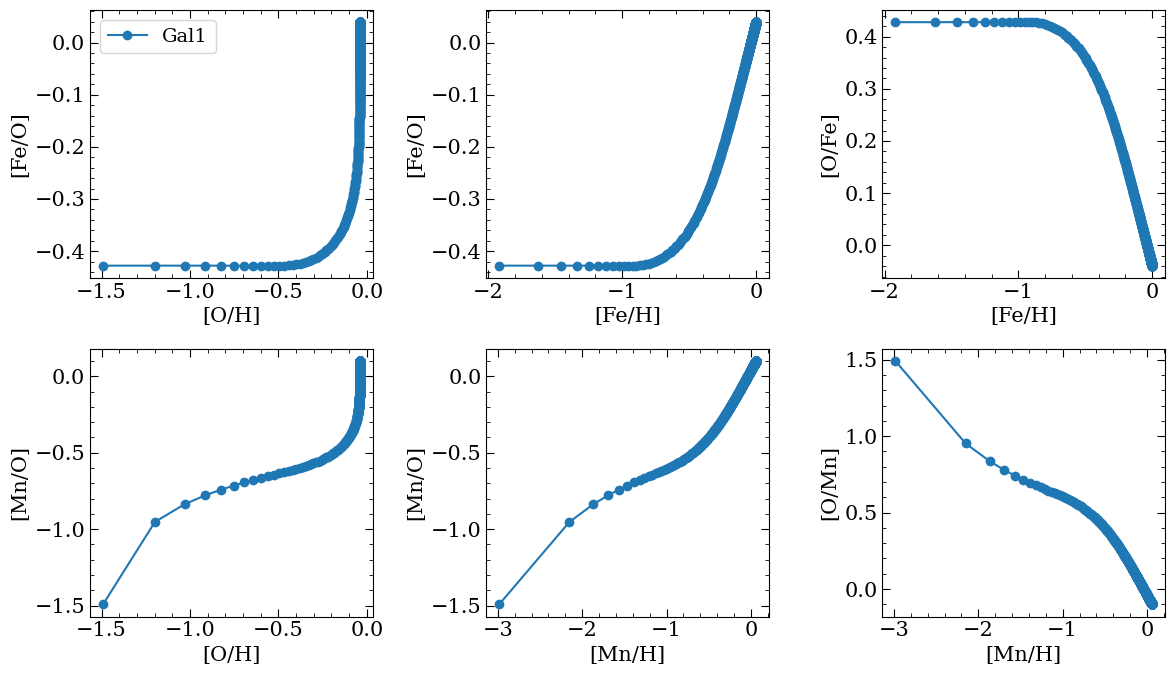

In [8]:
plt.figure(figsize=(12,7))

plt.subplot(2,3,1)
plt.plot(gal1.O_H[1:], gal1.Fe_O[1:], label='Gal1', marker='o')
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')
plt.legend()

plt.subplot(2,3,2)
plt.plot(gal1.Fe_H[1:], gal1.Fe_O[1:], marker='o')
plt.xlabel('[Fe/H]')
plt.ylabel('[Fe/O]')

plt.subplot(2,3,3)
plt.plot(gal1.Fe_H[1:], gal1.O_Fe[1:], marker='o')
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe]')

plt.subplot(2,3,4)
plt.plot(gal1.O_H[1:], Mn_O[1:], marker='o')
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')

plt.subplot(2,3,5)
plt.plot(gal1.Mn_H[1:], Mn_O[1:], marker='o')
plt.xlabel('[Mn/H]')
plt.ylabel('[Mn/O]')

plt.subplot(2,3,6)
plt.plot(gal1.Mn_H[1:], O_Mn[1:], marker='o')
plt.xlabel('[Mn/H]')
plt.ylabel('[O/Mn]')

plt.tight_layout()
plt.show()


In [9]:
#Gal4, with alpha_cc=0
gal4 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, alpha_cc_Mn=0)
Z_Fe_4 = gal4.compute_z_Fe()
Z_O_4 = gal4.compute_z_O()
Z_Mn_4 = gal4.compute_z_Mn()

gal5 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, alpha_Ia_Mn=0)
Z_Fe_5 = gal5.compute_z_Fe()
Z_O_5 = gal5.compute_z_O()
Z_Mn_5 = gal5.compute_z_Mn()

In [10]:
#important times
tau_sfh = gal1.tau_sfh_arr[0]
tau_star = gal1.tau_star_arr[0]
tau_Ia = gal1.tau_Ia_arr_1[0]
t_D = gal1.t_D

mask_tau_sfh = np.where(np.isclose(gal1.t, tau_sfh, atol=1e-2))
mask_tau_star = np.where(np.isclose(gal1.t, tau_star, atol=1/2*1e-2))
mask_tau_Ia = np.where(np.isclose(gal1.t, tau_Ia, atol=1e-2))
mask_t_D = np.where(np.isclose(gal1.t, t_D, atol=1/2*1e-2))

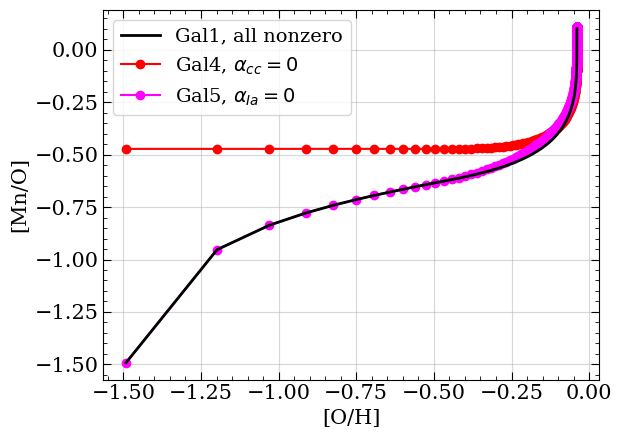

In [11]:
plt.plot(gal1.O_H[1:], gal1.Mn_O[1:], label = 'Gal1, all nonzero', color = 'black', marker='', zorder=4., lw=2)
plt.plot(gal4.O_H[1:], gal4.Mn_O[1:], label = r'Gal4, $\alpha_{cc} = 0$', color = 'red', marker='o')
plt.plot(gal5.O_H[1:], gal5.Mn_O[1:], label = r'Gal5, $\alpha_{Ia} = 0$', color = 'magenta', marker='o')

#plt.axvline(gal1.O_H[mask_tau_sfh], label = r't = $\tau_{sfh}$', color = 'blue')
#plt.axvline(gal1.O_H[mask_tau_star[0]], label = r't = $\tau_*$', color = 'navy', linestyle='--')
#plt.axvline(gal1.O_H[mask_tau_Ia], label = r't = $\tau_{Ia}$', color = 'teal', linestyle=':')
#plt.axvline(gal1.O_H[mask_t_D], label = r't = $t_D$', color = 'aqua', linestyle='-.')
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')
plt.grid('True', alpha = 0.5)
plt.legend()


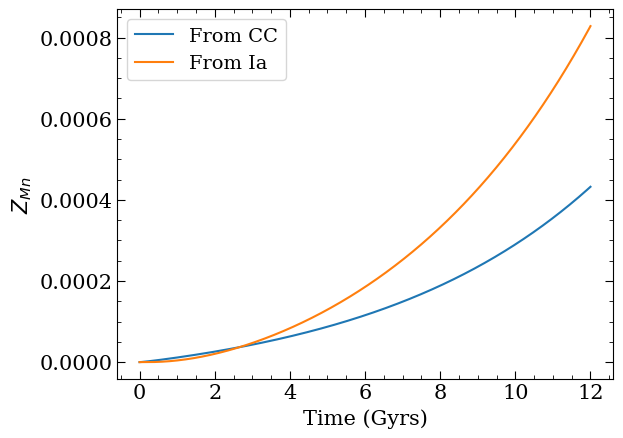

In [12]:
plt.plot(t_array, gal1.z_Mn_from_cc, label = 'From CC')
plt.plot(t_array, gal1.z_Mn_from_Ia, label = 'From Ia')

plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}$')
plt.legend()

# Different outflow variations, for Mn (Figure 17, Cartography paper)


Text(0.5, 0, '[O/H]')

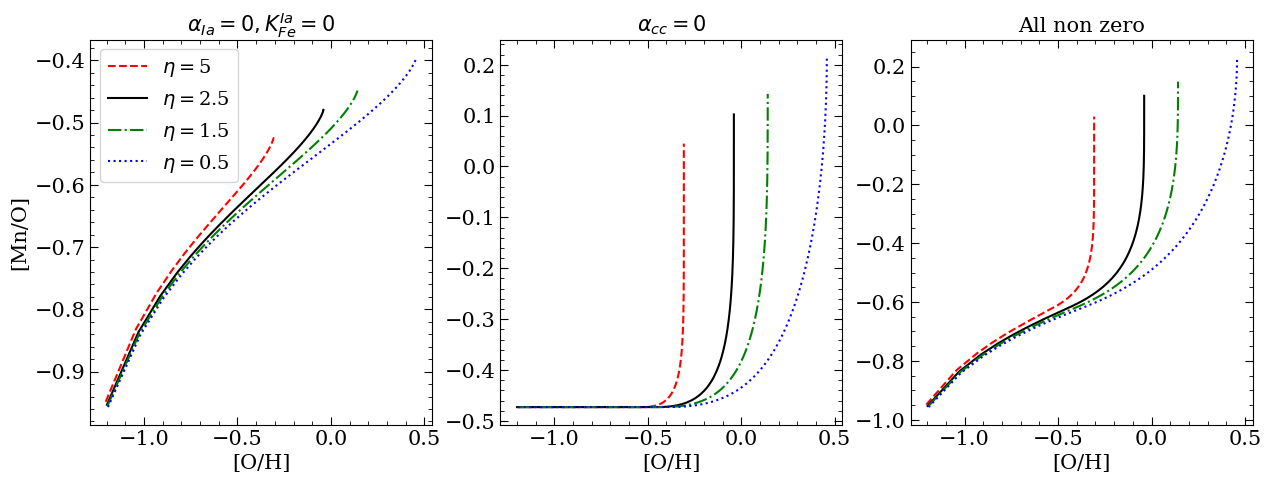

In [13]:
etas = [5, 2.5, 1.5, 0.5]
colors = ['red', 'black', 'green', 'blue']
styles = ['--', '-', '-.', ':']
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title(r'$\alpha_{Ia} = 0, K_{Fe}^{Ia} = 0$')   
for i in range(len(etas)):
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, eta=etas[i],
                          alpha_Ia_Mn=0, K_Fe_Ia=0, m_Fe_Ia=0)
    
    plt.plot(gal_temp.O_H[2:], gal_temp.Mn_O[2:], color = colors[i],
                label = r"$\eta = $" + f"{etas[i]}", linestyle=styles[i])
    
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')
plt.legend()

plt.subplot(1,3,2)
plt.title(r'$\alpha_{cc} = 0$')   
for i in range(len(etas)):
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, eta=etas[i], alpha_cc_Mn=0)
    
    plt.plot(gal_temp.O_H[2:], gal_temp.Mn_O[2:], color = colors[i],
                label = r"$\eta = $" + f"{etas[i]}", linestyle=styles[i])
    
 
plt.xlabel('[O/H]')

plt.subplot(1,3,3)
plt.title('All non zero') 
for i in range(len(etas)):
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, eta=etas[i])
    
    plt.plot(gal_temp.O_H[2:], gal_temp.Mn_O[2:], color = colors[i],
                label = r"$\eta = $" + f"{etas[i]}", linestyle=styles[i])
    
plt.xlabel('[O/H]')

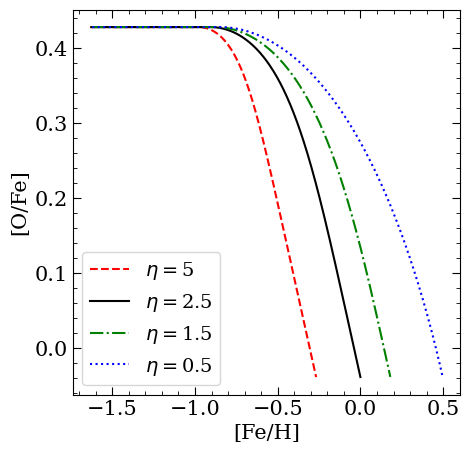

In [14]:
plt.figure(figsize=(5,5))
for i in range(len(etas)):
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, eta=etas[i])
    
    plt.plot(gal_temp.Fe_H[2:], gal_temp.O_Fe[2:], color = colors[i],
                label = r"$\eta = $" + f"{etas[i]}", linestyle=styles[i])
    
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe]')
plt.legend()

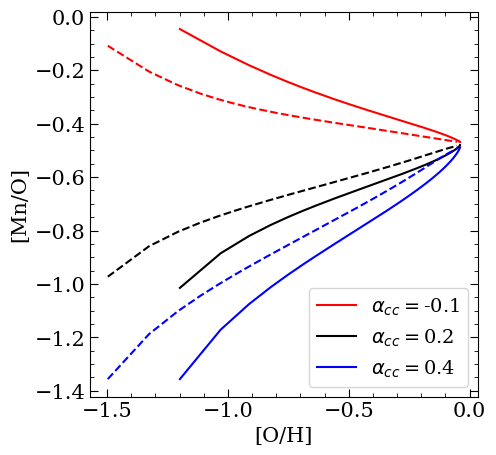

In [15]:
alpha_ccs = [-0.1, 0.2, 0.4]
colors_2 = ['red', 'black', 'blue']
m_g_array_lin_exp = t_array/tau_sfh * np.exp(-t_array/tau_sfh)
plt.figure(figsize=(5,5))
for i in range(len(alpha_ccs)):
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, K_Fe_Ia=0, alpha_cc_Mn=alpha_ccs[i])

    t_arr = t_array[1:]
    m_g_array_lin_exp = t_arr/tau_sfh * np.exp(-t_arr/tau_sfh)
    gal_temp_linexp = evo.Galaxy(t_array=t_arr, m_g_array=m_g_array_lin_exp, K_Fe_Ia=0, alpha_cc_Mn=alpha_ccs[i])
    plt.plot(gal_temp.O_H[2:], gal_temp.Mn_O[2:], color = colors_2[i],
                label = r"$\alpha_{cc} = $" + f"{alpha_ccs[i]}")
    plt.plot(gal_temp_linexp.O_H[2:], gal_temp_linexp.Mn_O[2:], color = colors_2[i], linestyle = '--')
    
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')
plt.legend()

Why doesn't Mn work with lin-exp??? will it work with const? let's try